Author:  
Manuel Eugenio Morocho Cayamcela, PhD

## Pattern Extraction from the California Housing Prices Data

### **Objective and Scope of the Work:**

This practical test focuses on exploratory data analysis and visualization of a housing dataset. The dataset contains information about housing characteristics, such as geographic location, size, number of rooms, median price, and proximity to the ocean.

The main goal of this notebook is to understand the relationships between the different housing characteristics. To do this, we will carry out a series of tasks, including data cleaning, transforming categorical variables into numerical ones, calculating correlations between variables, and visualizing these correlations.

By the end of this notebook, we will have a better understanding of how the different housing characteristics relate to each other, which will allow us to carry out more detailed analyses in the future.

The 'california_housing_prices.csv' dataset contains information about housing prices in California. The variables in the dataset are as follows:

1. longitude: The geographic longitude of the house's location.
2. latitude: The geographic latitude of the house's location.
3. housing_median_age: The median age of the houses in the location.
4. total_rooms: The total number of rooms in the house.
5. total_bedrooms: The total number of bedrooms in the house.
6. population: The total population in the location.
7. households: The total number of households in the location.
8. median_income: The median household income in the location.
9. median_house_value: The median house value in the location.
10. ocean_proximity: The house's proximity to the ocean.

The dataset contains a total of 20,640 records. The variables have different data types, with most being numerical (float64) and one categorical (object). Some variables have missing values in the dataset.

### **Phase I:** Data Loading and Initial Exploratory Analysis

In [1]:
%pip install seaborn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import the 'pandas' library as 'pd', 'seaborn' as 'sns', and 'matplotlib.pyplot' as 'plt'
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load the 'california_housing_prices.csv' dataset into a DataFrame called 'housing'
housing = pd.read_csv('../../Datasets/california_housing_prices.csv')

In [4]:
# Use the 'head()' method to display the first 15 rows of the 'housing' DataFrame
housing.head(15)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [5]:
# Use the 'describe()' method to get descriptive statistics of the 'housing' DataFrame
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
# Use the 'info()' method to get information about the 'housing' DataFrame
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### **Phase II:** Data Visualization

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

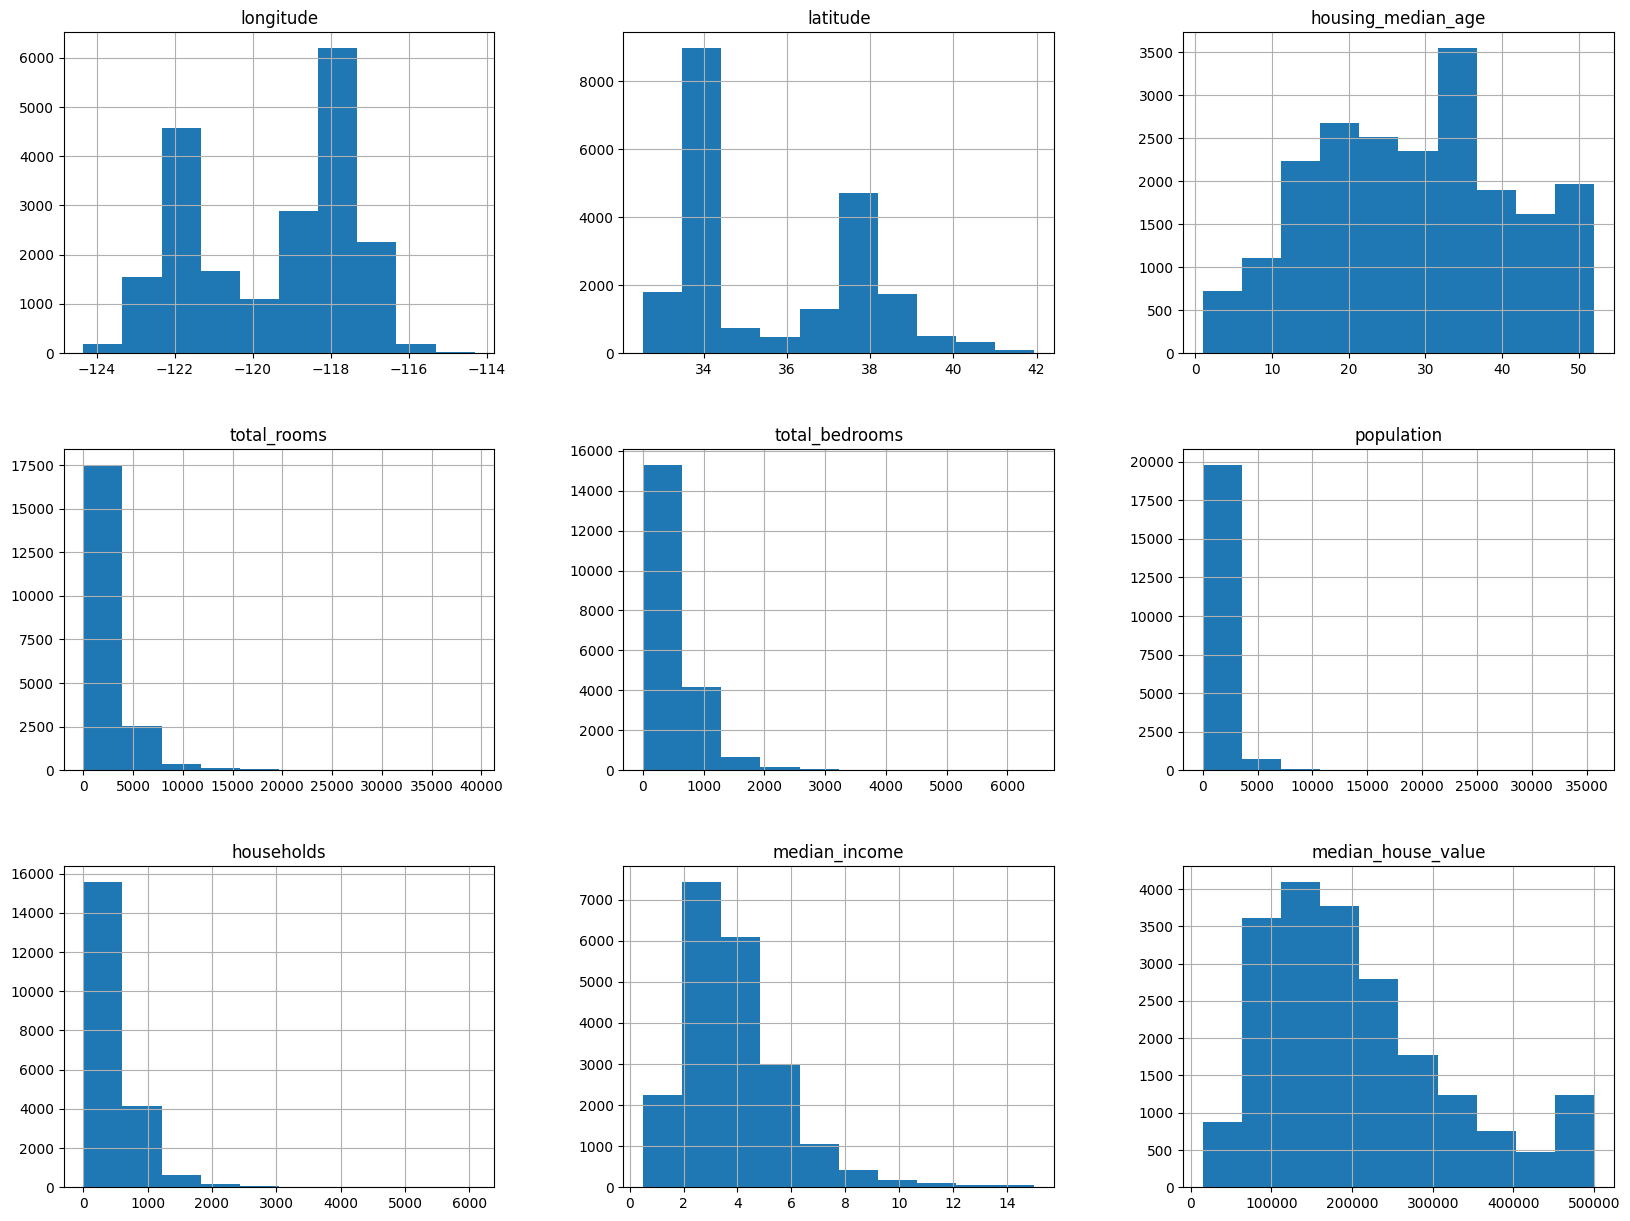

In [7]:
# Use pandas' 'hist()' method to display a histogram of all columns in the 'housing' DataFrame, with a figure size of 20x15
housing.hist(figsize=(20, 15))

<Axes: xlabel='longitude', ylabel='latitude'>

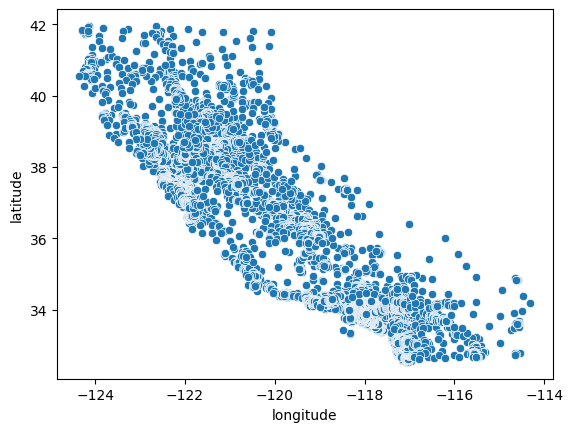

In [8]:
# Use the 'seaborn' library to display a scatterplot of the 'longitude' and 'latitude' columns of the houses in California (DataFrame 'housing')

sns.scatterplot(x='longitude', y='latitude', data=housing)

<Axes: xlabel='longitude', ylabel='latitude'>

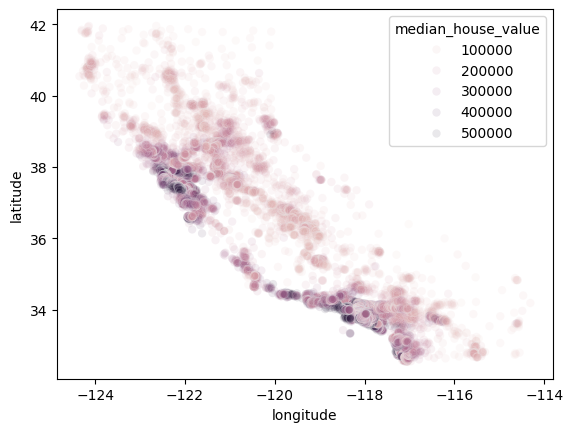

In [9]:
# Use the 'seaborn' library to display a scatterplot of the 'longitude' and 'latitude' columns of the houses in California (DataFrame 'housing')
# We use the opacity parameter 'alpha' of 0.1. This means the points will have 10% opacity. This is useful when we have many points and want to visualize density
# We use the 'hue' parameter to add an additional dimension to the plot by coloring the data points according to the 'median_house_value' variable
sns.scatterplot(x='longitude', y='latitude', data=housing, alpha=0.1, hue='median_house_value')

<Axes: xlabel='longitude', ylabel='latitude'>

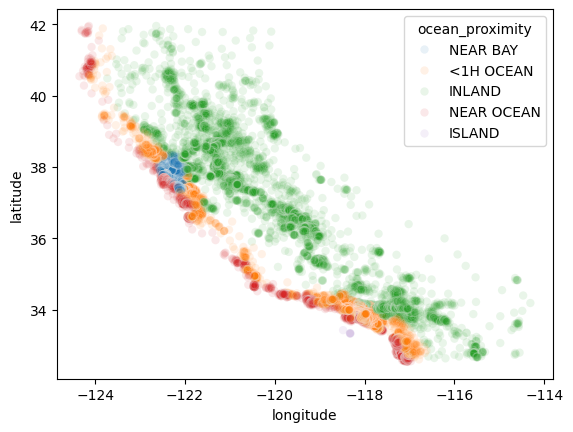

In [10]:
# Use the 'seaborn' library to display a scatterplot of the 'longitude' and 'latitude' columns of the houses in California, with color intensity representing proximity to the ocean
sns.scatterplot(x='longitude', y='latitude', data=housing, alpha=0.1, hue='ocean_proximity')

### **Phase III:** Correlation and Data Profiling with [ydata_profiling](https://docs.profiling.ydata.ai/latest/)

In [11]:
# Install the 'ydata_profiling' library (Pandas Profiling) in the development environment
%pip install ydata_profiling

# Import the 'ProfileReport' class from 'ydata_profiling'
from ydata_profiling import ProfileReport

# Use Pandas Profiler to generate a data profiling report of the 'housing' DataFrame
profile = ProfileReport(housing, title='Data Profiling Report', explorative=True)
profile.to_notebook_iframe()

# Optional: To generate a data profiling report in HTML format, use the 'to_file()' method of the 'ProfileReport' class
# profile.to_file("data_profiling_report.html")

Note: you may need to restart the kernel to use updated packages.


C:\Users\jgram\AppData\Local\Temp\ipykernel_14436\1727534220.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 72.19it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]